# MC Dropout — MIT Reactor

This is a multi-output regression model

**Inputs:**
| Variable | Description |  |
|----------|-------------|-------|
| `CR1` | Control rod 1 height | cm |
| `CR2` | Control rod 2 height | cm |
| `CR3` | Control rod 3 height | cm |
| `CR4` | Control rod 4 height | cm |
| `CR5` | Control rod 5 height | cm |
| `CR6` | Control rod 6 height | cm |

**Outputs (22 fuel element pin powers):**
- `A-2, B-1, B-2, ..., C-15`: Pin power in each fuel element (W)

## MC Dropout

Standard neural networks produce a single point estimate with no measure of confidence. MC Dropout approximates Bayesian inference:

1. Train a network with dropout layers
2. At inference time, keep dropout active by calling the model with `training=True`
3. Run N stochastic forward passes — each applies a different random dropout mask, effectively sampling a different thinned sub-network
4. Treat the N predictions as samples from an approximate posterior predictive distribution

For multi-output models, every one of the 22 outputs gets its own predictive distribution — uncertainty is estimated per output, per sample.

## 1. Imports

In [26]:
# import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# print(f'TensorFlow : {tf.__version__}')
# print(f'NumPy      : {np.__version__}')
# print(f'Seed       : {SEED}')

## 2. Data Loading

load two CSV files:
- `crx.csv` — 6 control rod heights (inputs X)
- `powery.csv` — 22 fuel element pin powers (outputs y)

In [27]:
# Load file
crx = pd.read_csv('crx.csv')
pwr = pd.read_csv('powery.csv')

print(f'Inputs shape: {crx.shape}  — {crx.shape[1]} control rods x {crx.shape[0]} samples')
print(f'Outputs shape: {pwr.shape}  — {pwr.shape[1]} pin powers   x {pwr.shape[0]} samples')
print(f'Missing values: {crx.isnull().sum().sum()}')
print(f'Missing values: {pwr.isnull().sum().sum()}')
print()
print('Input columns :', list(crx.columns))
print('Output columns:', list(pwr.columns))

Inputs shape: (1000, 6)  — 6 control rods x 1000 samples
Outputs shape: (1000, 22)  — 22 pin powers   x 1000 samples
Missing values: 0
Missing values: 0

Input columns : ['CR1', 'CR2', 'CR3', 'CR4', 'CR5', 'CR6']
Output columns: ['A-2', 'B-1', 'B-2', 'B-4', 'B-5', 'B-7', 'B-8', 'C-1', 'C-2', 'C-3', 'C-4', 'C-5', 'C-6', 'C-7', 'C-8', 'C-9', 'C-10', 'C-11', 'C-12', 'C-13', 'C-14', 'C-15']


In [28]:
crx.describe()

,CR1,CR2,CR3,CR4,CR5,CR6
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,24.002362,24.002247,24.002239,24.002296,24.002215,24.002347
std,2.307388,2.307477,2.307274,2.307439,2.307392,2.307240
min,20.015728,20.015688,20.011666,20.015196,20.014167,20.010098
25%,22.008250,22.003415,22.005339,22.006215,22.008519,22.004907
50%,24.002348,24.001948,24.003459,24.001979,24.002157,24.002589
75%,25.997588,25.999054,25.994646,25.998070,25.999272,25.999768
max,27.988949,27.990569,27.996519,27.993931,27.992302,27.996674


In [29]:
pwr.describe()

,A-2,B-1,B-2,B-4,B-5,B-7,B-8,C-1,C-2,C-3,...,C-6,C-7,C-8,C-9,C-10,C-11,C-12,C-13,C-14,C-15
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,25857.948944,22751.973142,21571.043267,22829.124973,21855.021509,22776.072309,21199.175990,17995.687992,18055.293658,18645.504104,...,19150.610363,18586.583045,18859.531683,18546.736670,19471.060450,18459.995084,17757.572095,18020.770800,17932.678094,18741.349101
std,111.737065,137.724890,149.214567,128.411467,132.613015,130.878789,137.069060,288.339948,346.150943,368.239155,...,307.444903,338.193028,355.422499,341.144200,310.545769,298.627922,325.520498,336.781257,314.329523,264.535923
min,25576.491089,22395.330383,21177.919128,22538.634888,21483.759766,22407.609314,20847.516357,17225.177856,17295.053223,17751.612122,...,18399.550537,17856.314270,17967.381104,17813.881897,18788.292542,17729.762085,16993.138519,17115.435364,17217.376099,18010.469421
25%,25784.029114,22651.787201,21462.230209,22735.518463,21759.725937,22683.478317,21106.676178,17771.878693,17776.104889,18372.997459,...,18908.928879,18303.160980,18606.547462,18255.070236,19213.951614,18235.885422,17499.151848,17785.954018,17686.204620,18541.808990
50%,25854.868958,22755.613159,21569.500275,22822.123138,21849.713837,22777.467346,21199.536041,18016.902603,18059.735565,18640.354080,...,19146.648651,18577.785095,18856.972275,18545.650085,19467.694763,18461.777771,17747.462128,18006.664551,17931.348358,18751.753784
75%,25936.421997,22850.217926,21679.453171,22915.561691,21942.956772,22870.423904,21295.445602,18210.270683,18332.361931,18912.009430,...,19377.632019,18847.725769,19112.168510,18841.933258,19723.220978,18704.255859,18015.015579,18253.680847,18192.969223,18953.056808
max,26165.800781,23117.525452,22001.000854,23231.956604,22272.937195,23102.876282,21580.143372,18693.776093,18906.377563,19575.140076,...,20027.868347,19442.597534,19687.460754,19275.817261,20163.349243,19174.291016,18503.664062,18929.360077,18621.790894,19369.918152


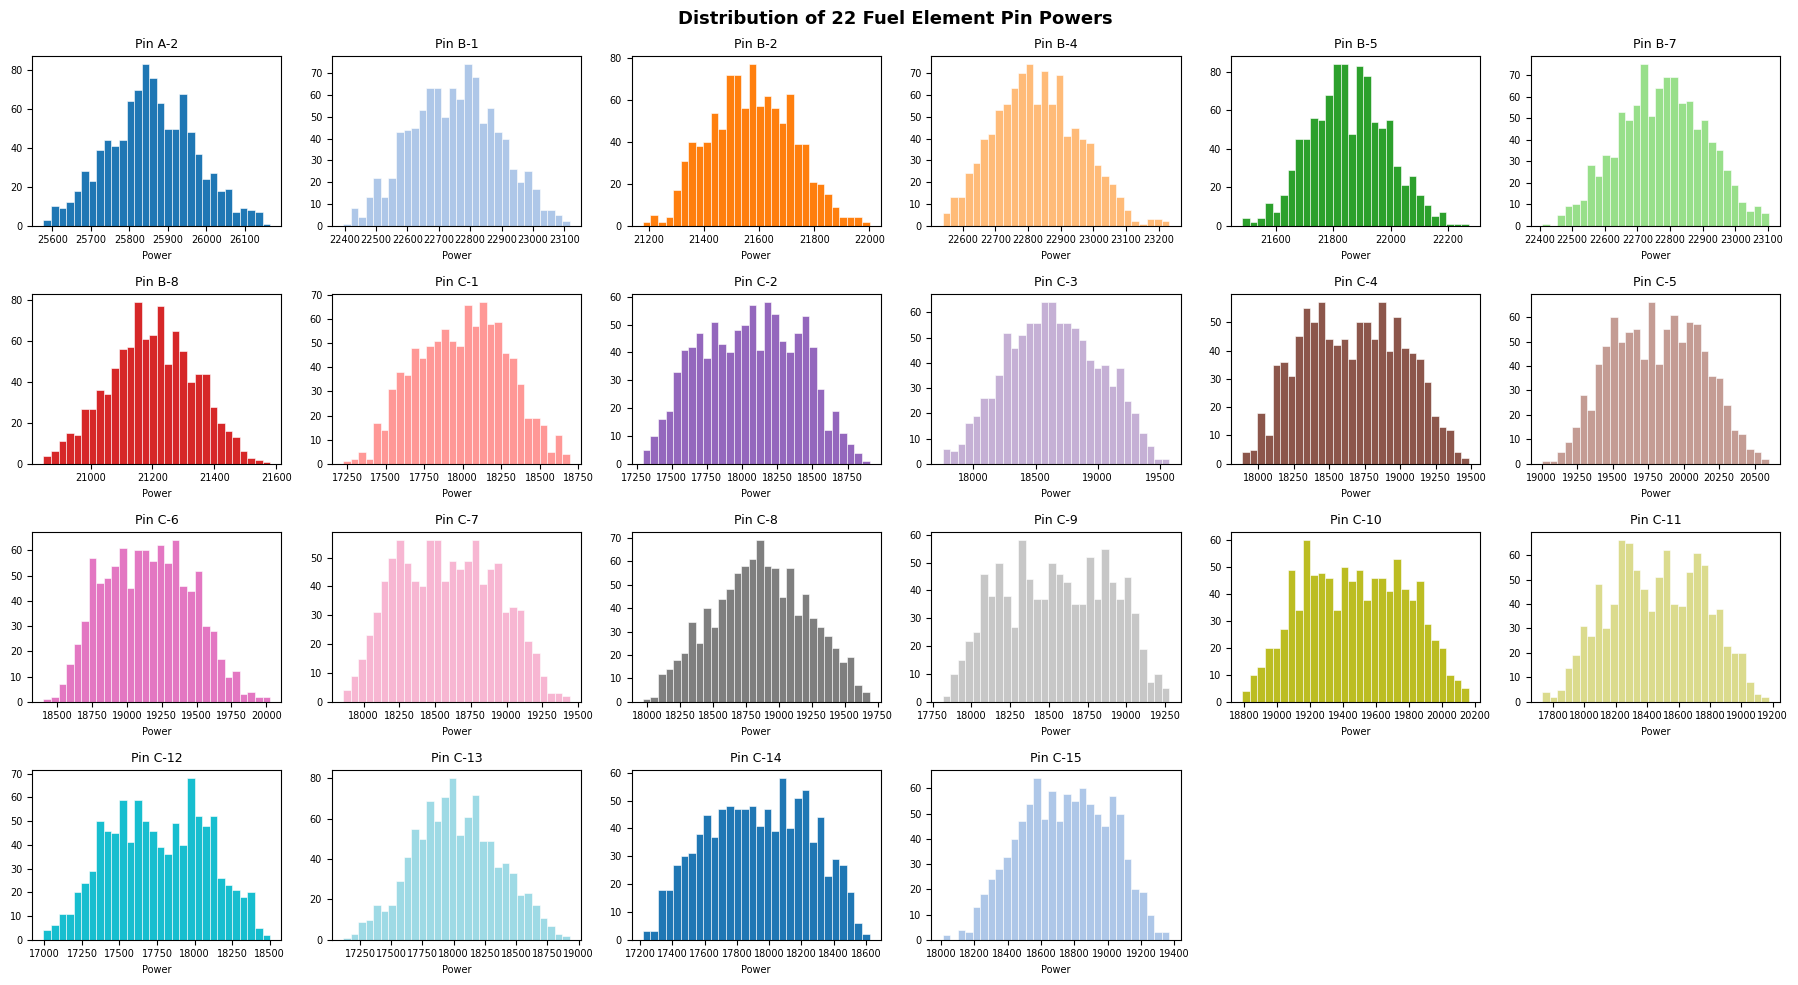

In [30]:
# Visualise the distribution of all 22 power outputs
fig, axes = plt.subplots(4, 6, figsize=(18, 10))
axes = axes.ravel()
colors = plt.cm.tab20.colors

for i, col in enumerate(pwr.columns):
    axes[i].hist(pwr[col], bins=30, color=colors[i % 20], edgecolor='white', linewidth=0.4)
    axes[i].set_title(f'Pin {col}', fontsize=9)
    axes[i].set_xlabel('Power', fontsize=7)
    axes[i].tick_params(labelsize=7)

for j in range(len(pwr.columns), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of 22 Fuel Element Pin Powers', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

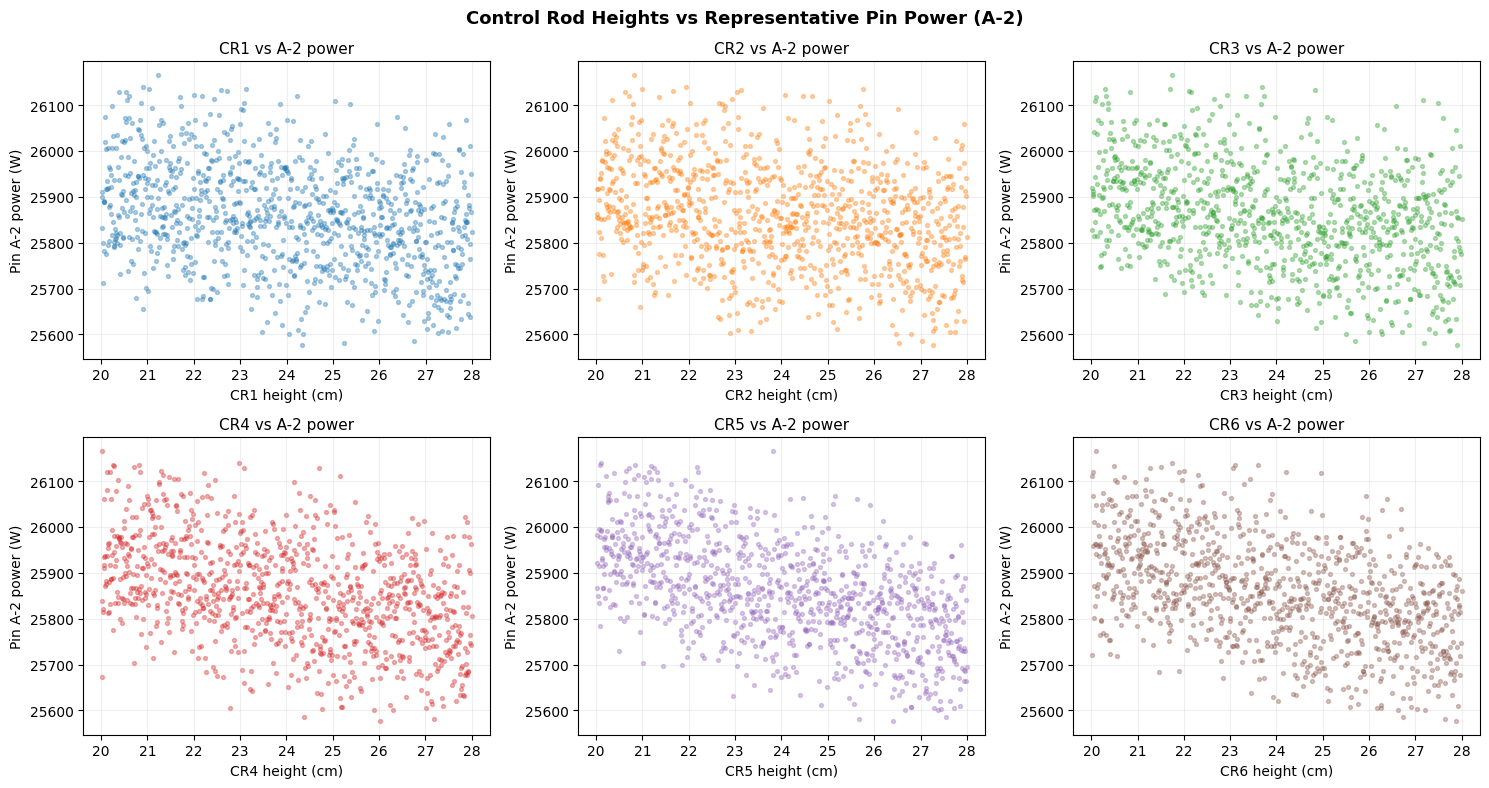

In [31]:
# Visualise each control rod vs. the first few pin powers to understand correlations
# We expect negative correlations: deeper control rods absorb more neutrons → lower power
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
colors_cr = plt.cm.tab10.colors

for i, col in enumerate(crx.columns):
    axes[i].scatter(crx[col], pwr['A-2'], s=8, alpha=0.35, color=colors_cr[i])
    axes[i].set_xlabel(f'{col} height (cm)', fontsize=10)
    axes[i].set_ylabel('Pin A-2 power (W)', fontsize=10)
    axes[i].set_title(f'{col} vs A-2 power', fontsize=11)
    axes[i].grid(True, alpha=0.2)

fig.suptitle('Control Rod Heights vs Representative Pin Power (A-2)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:** Each control rod affects pin power negatively (deeper insertion → lower power). The relationship is approximately linear but with scatter from the simultaneous effect of all 6 rods.

## 3. Train/Test Split and Scaling

- 70% train / 30% test
- StandardScaler
- Output scaler (`y_scaler`) is preserved to inverse-transform predictions back to Watts

In [32]:

X = crx.values.astype(np.float64)
y = pwr.values.astype(np.float64)

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)


x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)

y_scaler  = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train)

print(f'\nTraining samples: {X_train_s.shape[0]}')
print(f'Test samples: {X_test_s.shape[0]}')
print(f'Input features: {X_train_s.shape[1]}')
print(f'Output targets: {y_train_s.shape[1]}')
print(f'y_train scaled range: [{y_train_s.min():.3f}, {y_train_s.max():.3f}]')

X (inputs)  shape : (1000, 6)
y (outputs) shape : (1000, 22)

Training samples    : 700
Test samples        : 300
Input features      : 6
Output targets      : 22
y_train scaled range: [-2.821, 3.141]


## 4. Model Architecture — MC Dropout Neural Network (Multi-Output)

### Design Decisions

| Choice | Value                                  | Reason                                                                                 |
|--------|----------------------------------------|----------------------------------------------------------------------------------------|
| Hidden layers | 3                                      | like the branchmark                                                                    |
| Units per layer | 256 → 256 → 128                        | best when test                                                                         |
| Activation | ReLU                                   | Standard activation function                                   |
| Dropout rate | 0.1                                    | Normal dropout rate to use                         |
| **Output size** | 22                                     | One neuron per fuel element                    |
| **MC Dropout mechanism** | `model(X, training=True)` at inference | Passes the training flag through the full call graph, keeping all Dropout layers active |
| Loss | MSE                                    |                                                               |
| Optimizer | Adam lr=0.001                          |                                                                      |


In [48]:
#hyperparameters
N_INPUTS      = X_train_s.shape[1]
N_OUTPUTS     = y_train_s.shape[1]
DROPOUT_RATE  = 0.1
LEARNING_RATE = 1e-3
BATCH_SIZE    = 32
MAX_EPOCHS    = 300
MC_SAMPLES    = 100   # number of stochastic forward passes at inference

print(f"N_INPUTS: {N_INPUTS}")
print(f"N_OUTPUTS: {N_OUTPUTS}")

def build_mc_dropout_model(input_dim: int, output_dim: int, dropout_rate: float = DROPOUT_RATE) -> keras.Model:

    inputs = keras.Input(shape=(input_dim,), name='control_rod_heights')

    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal', name='dense_1')(inputs)
    x = layers.Dropout(dropout_rate, name='dropout_1')(x)

    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal', name='dense_2')(x)
    x = layers.Dropout(dropout_rate, name='dropout_2')(x)

    x = layers.Dense(128, activation='relu', kernel_initializer='he_normal', name='dense_3')(x)
    x = layers.Dropout(dropout_rate, name='dropout_3')(x)

    # Output layer: 22 neurons with linear activation — one per fuel element
    output = layers.Dense(output_dim, activation='linear', name='pin_powers')(x)

    model = keras.Model(inputs=inputs, outputs=output, name='MC_Dropout_MITR_MultiOutput')
    return model


model = build_mc_dropout_model(input_dim=N_INPUTS, output_dim=N_OUTPUTS)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
)
model.summary()

N_INPUTS: 6
N_OUTPUTS: 22


Model: "MC_Dropout_MITR_MultiOutput"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ control_rod_heights             │ (None, 6)              │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pin_powers (Dense)              │ (None, 22)             │         2,838 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,318 (403.59 KB)

 Trainable params: 103,318 (403.59 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Training

In [49]:

# early_stop = keras.callbacks.EarlyStopping(
#     monitor='val_loss', patience=30, restore_best_weights=True, verbose=1
# )
# reduce_lr = keras.callbacks.ReduceLROnPlateau(
#     monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=0
# )

# 15% of training data withheld for validation
history = model.fit(
    X_train_s, y_train_s,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,
    # callbacks=[early_stop, reduce_lr],
    verbose=0,
)

epochs_ran = len(history.history['loss'])
best_val   = min(history.history['val_loss'])
#print(f'Training complete. Epochs: {epochs_ran}  |  Best val MSE: {best_val:.6f}')

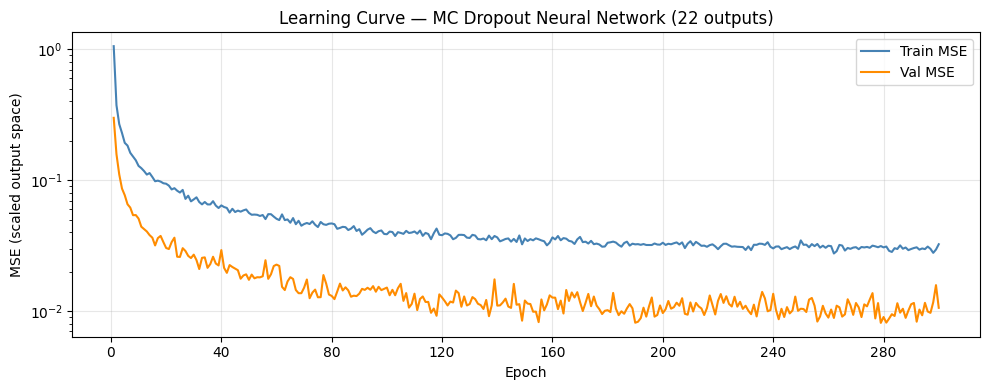

In [50]:
# Learning curve in log scale
fig, ax = plt.subplots(figsize=(10, 4))
ep = range(1, epochs_ran + 1)
ax.semilogy(ep, history.history['loss'],     label='Train MSE', color='steelblue', linewidth=1.5)
ax.semilogy(ep, history.history['val_loss'], label='Val MSE',   color='darkorange', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled output space)')
ax.set_title('Learning Curve — MC Dropout Neural Network (22 outputs)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. MC Dropout Inference

With the trained model, we perform MC Dropout inference. Calling `model(X, training=True)` N times produces N predictions with different random dropout masks applied at each Dropout layer.


In [51]:
def mc_predict(model, X, n_samples: int = MC_SAMPLES):
    """
    Run n_samples stochastic forward passes with dropout active.

    model(X, training=True) propagates the training flag to all layers,
    keeping Dropout active during inference. Each call applies a different
    random dropout mask, producing a different set of 22 predictions.
    Stacking N such calls gives a (N, n_test, 22) tensor representing
    N samples from the approximate posterior predictive distribution.

    Parameters
    model: trained Keras model
    X: scaled input array, shape (n_test, 6)
    n_samples: number of MC forward passes

    Returns ndarray of shape (n_samples, n_test, 22) in scaled output space
    """
    return np.stack(
        [model(X, training=True).numpy() for _ in range(n_samples)],
        axis=0
    )

raw_scaled = mc_predict(model, X_test_s.astype(np.float64))
print(f'MC prediction tensor shape : {raw_scaled.shape}  (n_passes x n_test x n_outputs)')

MC prediction tensor shape : (100, 300, 22)  (n_passes x n_test x n_outputs)


In [54]:
# Inverse-transform all MC samples from scaled space back to Watts
# raw_scaled shape: (MC_SAMPLES, n_test, 22)
# We reshape to (MC_SAMPLES * n_test, 22), inverse_transform, then reshape back
n_mc, n_test, n_out = raw_scaled.shape
preds_W = y_scaler.inverse_transform(raw_scaled.reshape(-1, n_out)).reshape(n_mc, n_test, n_out)
# preds_W shape: (100, 300, 22) — 100 MC passes, 300 test samples, 22 outputs


mean_pred = preds_W.mean(axis=0)
std_pred  = preds_W.std(axis=0)
ci_lo     = np.percentile(preds_W, 2.5,  axis=0)
ci_hi     = np.percentile(preds_W, 97.5, axis=0)

print(f'  Std dev range across all outputs and samples : [{std_pred.min():.1f}, {std_pred.max():.1f}]')
print()
print(f'  Mean prediction range : [{mean_pred.min():.1f}, {mean_pred.max():.1f}]')
print(f'  CI width range        : [{(ci_hi-ci_lo).min():.1f}, {(ci_hi-ci_lo).max():.1f}]')

  Std dev range across all outputs and samples : [8.0, 109.5]

  Mean prediction range : [17084.2, 26125.2]
  CI width range        : [28.8, 415.1]


## 7. Performance Metrics

(R², RMSE, MAE)

In [57]:
# Per-output regression metrics using the MC mean prediction
r2s   = [r2_score(y_test[:, i], mean_pred[:, i])                        for i in range(N_OUTPUTS)]
rmses = [np.sqrt(mean_squared_error(y_test[:, i], mean_pred[:, i]))     for i in range(N_OUTPUTS)]
maes  = [mean_absolute_error(y_test[:, i], mean_pred[:, i])             for i in range(N_OUTPUTS)]

# Per-output 95% CI coverage: fraction of true values within the CI
within = (y_test >= ci_lo) & (y_test <= ci_hi)   # (300, 22) boolean
coverage_per_output = within.mean(axis=0) * 100  # (22,) percentages
coverage_overall    = within.mean() * 100

# per-output summary table
metrics_df = pd.DataFrame({
    'Fuel Element' : pwr.columns,
    'R2'           : [f'{v:.4f}' for v in r2s],
    'RMSE (W)'     : [f'{v:.1f}'  for v in rmses],
    'MAE (W)'      : [f'{v:.1f}'  for v in maes],
    '95% CI Coverage (%)': [f'{v:.1f}' for v in coverage_per_output],
    'Mean Std (W)' : [f'{std_pred[:, i].mean():.1f}' for i in range(N_OUTPUTS)],
})


print(metrics_df.to_string(index=False))
print()
print(f'  Mean R2: {np.mean(r2s):.4f}')
print(f'  Min / Max R2: {np.min(r2s):.4f} / {np.max(r2s):.4f}')
print(f'  Mean RMSE: {np.mean(rmses):.1f} W')
print(f'  Mean MAE: {np.mean(maes):.1f} W')
print(f'  Overall 95% Coverage : {coverage_overall:.1f}% ')
print(f'  Mean CI Width: {(ci_hi-ci_lo).mean():.1f} W')
print(f'  Mean Predictive Std  : {std_pred.mean():.1f} W')
print(f'  MC Samples used: {MC_SAMPLES}')
print('=' * 65)

Fuel Element     R2 RMSE (W) MAE (W) 95% CI Coverage (%) Mean Std (W)
         A-2 0.9901     10.3     8.1                99.3         17.3
         B-1 0.9925     12.0     9.5                99.7         20.0
         B-2 0.9936     11.6     8.9                99.3         20.9
         B-4 0.9901     12.0     9.7                98.7         18.9
         B-5 0.9916     12.1     9.7                99.3         19.4
         B-7 0.9866     14.1    11.4                99.0         19.1
         B-8 0.9859     15.5    12.8                98.0         19.4
         C-1 0.9938     23.6    18.4               100.0         44.7
         C-2 0.9937     28.3    21.9                99.7         54.3
         C-3 0.9927     30.7    23.8                99.3         51.7
         C-4 0.9884     35.8    28.1                99.3         53.3
         C-5 0.9886     31.7    25.0                99.0         46.9
         C-6 0.9872     33.2    26.1                99.3         47.0
         C-7 0.9875 

## 8. Calibration Analysis

Overall Calibration Table (all 22 outputs combined)
 Target CI (%) Actual Coverage (%) Delta (pp)
            50                86.8      +36.8
            75                98.3      +23.3
            90                99.8       +9.8
            95               100.0       +5.0
            99               100.0       +1.0


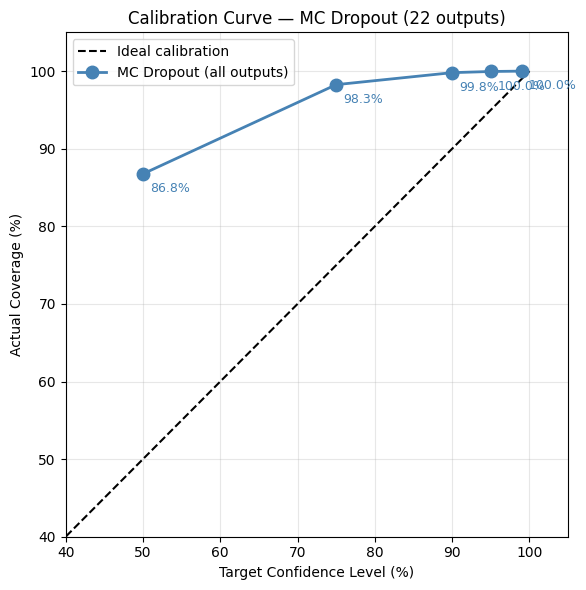

In [40]:
#multiple confidence levels in computed across all 22 outputs
confidence_levels = [50, 75, 90, 95, 99]
actual_coverages  = []

for conf in confidence_levels:
    alpha  = (100 - conf) / 2
    lo_tmp = np.percentile(preds_W, alpha,       axis=0)  # (n_test, 22)
    hi_tmp = np.percentile(preds_W, 100 - alpha, axis=0)
    actual_coverages.append(np.mean((y_test >= lo_tmp) & (y_test <= hi_tmp)) * 100)

calib_df = pd.DataFrame({
    'Target CI (%)':       confidence_levels,
    'Actual Coverage (%)': [f'{c:.1f}' for c in actual_coverages],
    'Delta (pp)':          [f'{a - t:+.1f}' for a, t in zip(actual_coverages, confidence_levels)],
})
print('Overall Calibration Table (all 22 outputs combined)')
print(calib_df.to_string(index=False))

# Calibration curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 100], [0, 100], 'k--', linewidth=1.5, label='Ideal calibration')
ax.plot(confidence_levels, actual_coverages, 'o-', color='steelblue',
        linewidth=2, markersize=9, label='MC Dropout (all outputs)')
for t, a in zip(confidence_levels, actual_coverages):
    ax.annotate(f'{a:.1f}%', xy=(t, a), xytext=(5, -13),
                textcoords='offset points', fontsize=9, color='steelblue')
ax.set_xlabel('Target Confidence Level (%)')
ax.set_ylabel('Actual Coverage (%)')
ax.set_title('Calibration Curve — MC Dropout (22 outputs)')
ax.set_xlim(40, 105); ax.set_ylim(40, 105)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Visualisations

### 9.1 Parity Plots with Uncertainty Bands


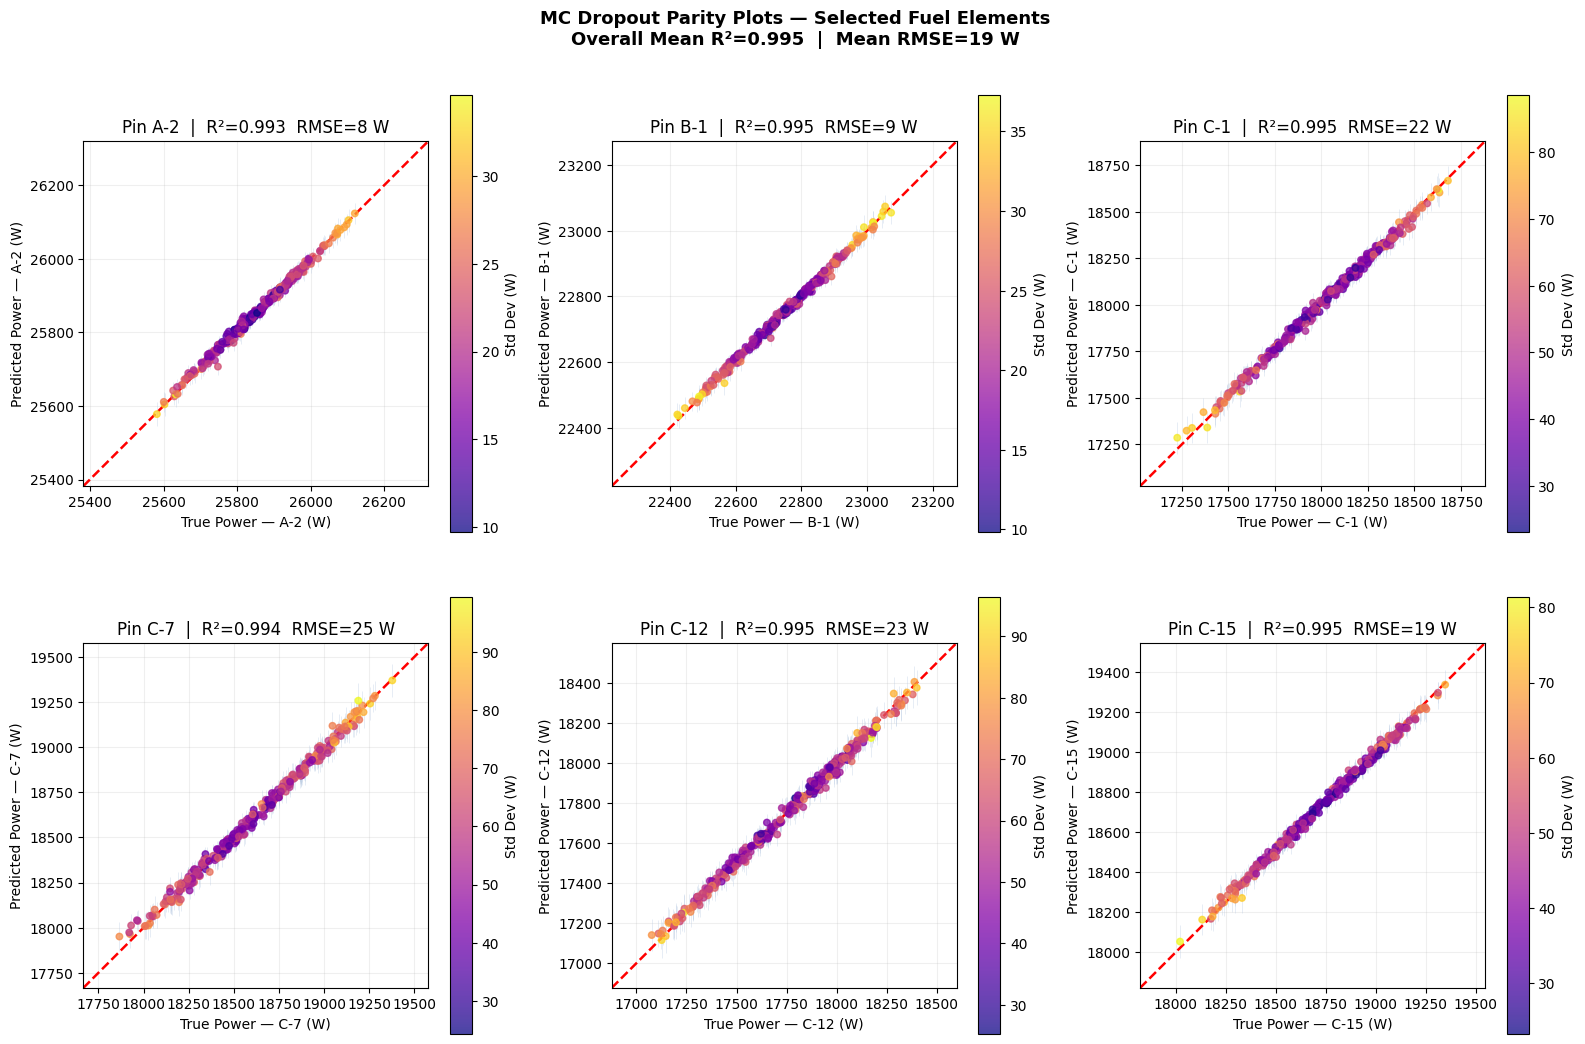

In [41]:
# Parity plots
selected_outputs = [0, 1, 7, 13, 18, 21]  # indices for A-2, B-1, C-1, C-7, C-12, C-15
selected_names   = [pwr.columns[i] for i in selected_outputs]

fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.ravel()

for ax_i, (idx_o, name) in enumerate(zip(selected_outputs, selected_names)):
    y_true_o  = y_test[:, idx_o]
    mean_o    = mean_pred[:, idx_o]
    std_o     = std_pred[:, idx_o]
    r2_o      = r2s[idx_o]
    rmse_o    = rmses[idx_o]

    ax = axes[ax_i]
    ax.errorbar(y_true_o, mean_o, yerr=std_o, fmt='none',
                ecolor='lightsteelblue', alpha=0.35, linewidth=0.6)
    sc = ax.scatter(y_true_o, mean_o, c=std_o, cmap='plasma', s=22, alpha=0.75, zorder=3)
    plt.colorbar(sc, ax=ax, label='Std Dev (W)', shrink=0.85)

    lims = [y_true_o.min() - 200, y_true_o.max() + 200]
    ax.plot(lims, lims, 'r--', linewidth=1.8, label='y = x (perfect)')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'True Power — {name} (W)')
    ax.set_ylabel(f'Predicted Power — {name} (W)')
    ax.set_title(f'Pin {name}  |  R²={r2_o:.3f}  RMSE={rmse_o:.0f} W')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

fig.suptitle(
    f'MC Dropout Parity Plots — Selected Fuel Elements\n'
    f'Overall Mean R²={np.mean(r2s):.3f}  |  Mean RMSE={np.mean(rmses):.0f} W',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

### 9.2 All-Output R² Bar Chart

This shows model performance across all 22 fuel elements.

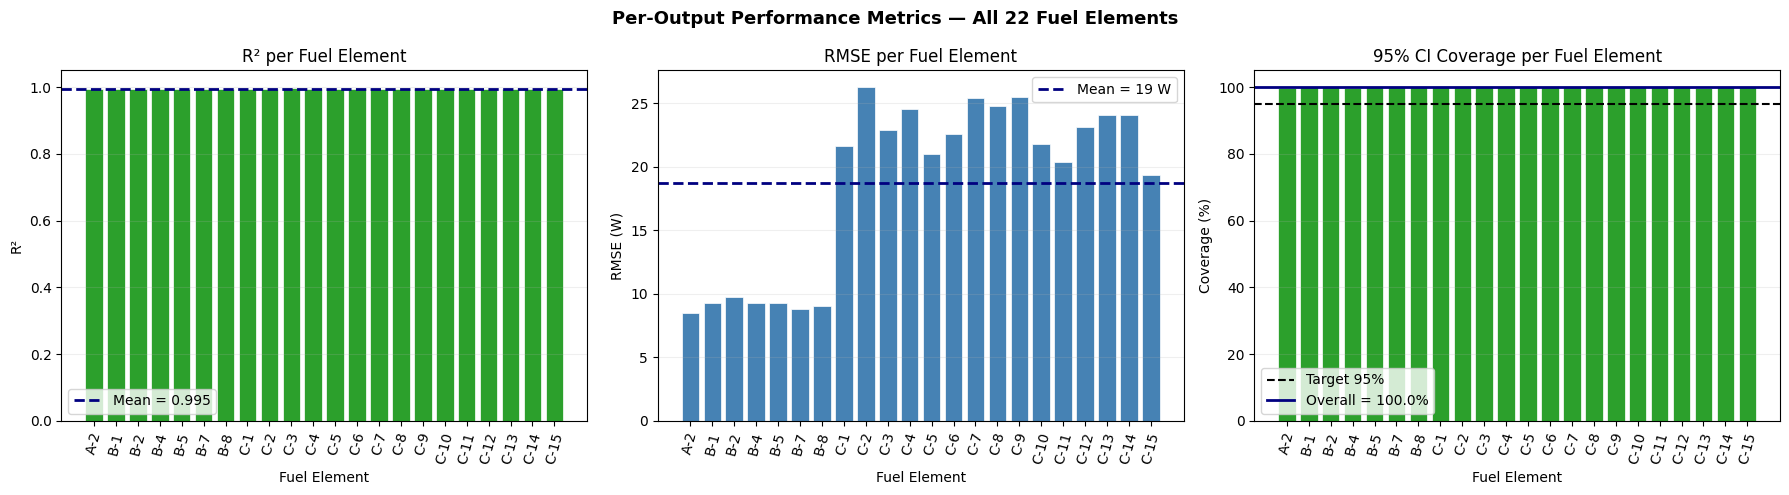

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# R2 per output
colors_bar = ['#d62728' if v < 0.9 else '#2ca02c' for v in r2s]
axes[0].bar(pwr.columns, r2s, color=colors_bar, edgecolor='white', linewidth=0.5)
axes[0].axhline(np.mean(r2s), color='navy', linewidth=2, linestyle='--', label=f'Mean = {np.mean(r2s):.3f}')
axes[0].set_xlabel('Fuel Element')
axes[0].set_ylabel('R²')
axes[0].set_title('R² per Fuel Element')
axes[0].tick_params(axis='x', rotation=75)
axes[0].legend()
axes[0].grid(True, alpha=0.2, axis='y')
axes[0].set_ylim(0, 1.05)

# RMSE per output
axes[1].bar(pwr.columns, rmses, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axhline(np.mean(rmses), color='navy', linewidth=2, linestyle='--', label=f'Mean = {np.mean(rmses):.0f} W')
axes[1].set_xlabel('Fuel Element')
axes[1].set_ylabel('RMSE (W)')
axes[1].set_title('RMSE per Fuel Element')
axes[1].tick_params(axis='x', rotation=75)
axes[1].legend()
axes[1].grid(True, alpha=0.2, axis='y')

# 95% CI coverage per output
colors_cov = ['#d62728' if v < 90 else '#2ca02c' for v in coverage_per_output]
axes[2].bar(pwr.columns, coverage_per_output, color=colors_cov, edgecolor='white', linewidth=0.5)
axes[2].axhline(95, color='black', linewidth=1.5, linestyle='--', label='Target 95%')
axes[2].axhline(coverage_overall, color='navy', linewidth=2, linestyle='-',
                label=f'Overall = {coverage_overall:.1f}%')
axes[2].set_xlabel('Fuel Element')
axes[2].set_ylabel('Coverage (%)')
axes[2].set_title('95% CI Coverage per Fuel Element')
axes[2].tick_params(axis='x', rotation=75)
axes[2].legend()
axes[2].grid(True, alpha=0.2, axis='y')
axes[2].set_ylim(0, 105)

fig.suptitle('Per-Output Performance Metrics — All 22 Fuel Elements', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 9.3 Predictions with 95% CI Ribbon (Single Output Example)

We show the ribbon plot for one representative output, sorted by true value for clarity.

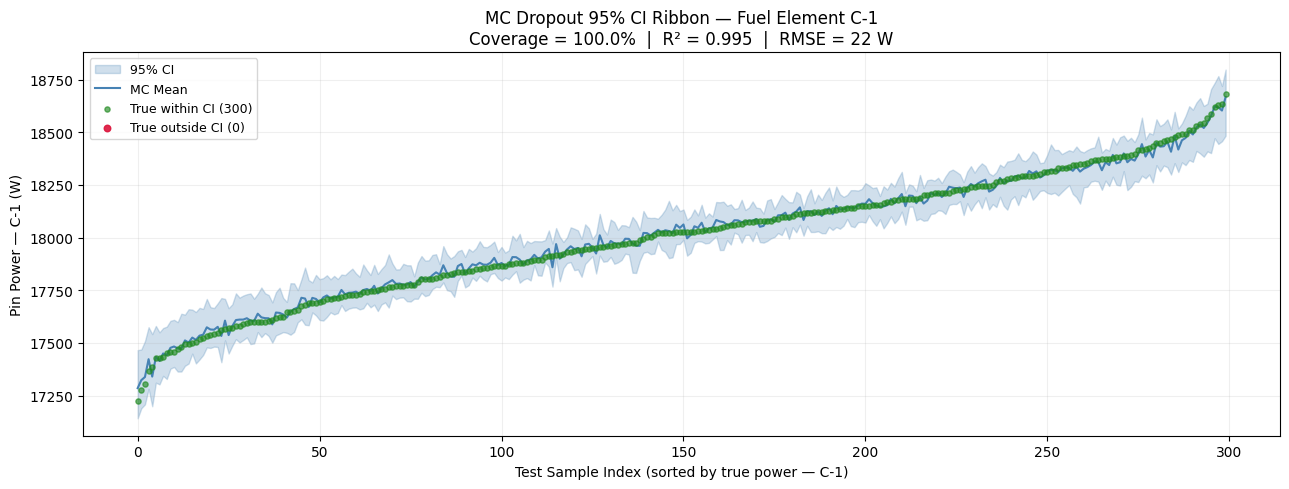

In [43]:
# Show ribbon plot for the output with median R2
median_idx   = int(np.argsort(r2s)[len(r2s) // 2])
median_name  = pwr.columns[median_idx]

y_true_m  = y_test[:, median_idx]
mean_m    = mean_pred[:, median_idx]
lo_m      = ci_lo[:, median_idx]
hi_m      = ci_hi[:, median_idx]
within_m  = (y_true_m >= lo_m) & (y_true_m <= hi_m)
cov_m     = within_m.mean() * 100

order     = np.argsort(y_true_m)
idx_arr   = np.arange(len(y_true_m))

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(idx_arr, lo_m[order], hi_m[order],
                alpha=0.25, color='steelblue', label='95% CI')
ax.plot(idx_arr, mean_m[order], color='steelblue', linewidth=1.5, label='MC Mean')
ax.scatter(idx_arr[ within_m[order]], y_true_m[order][ within_m[order]], s=14,
           color='forestgreen', alpha=0.65, zorder=3,
           label=f'True within CI ({within_m.sum()})')
ax.scatter(idx_arr[~within_m[order]], y_true_m[order][~within_m[order]], s=22,
           color='crimson', alpha=0.9, zorder=4,
           label=f'True outside CI ({(~within_m).sum()})')
ax.set_xlabel(f'Test Sample Index (sorted by true power — {median_name})')
ax.set_ylabel(f'Pin Power — {median_name} (W)')
ax.set_title(
    f'MC Dropout 95% CI Ribbon — Fuel Element {median_name}\n'
    f'Coverage = {cov_m:.1f}%  |  R² = {r2s[median_idx]:.3f}  |  RMSE = {rmses[median_idx]:.0f} W'
)
ax.legend(fontsize=9); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### 9.4 Posterior Distribution for a High-Uncertainty Sample

We visualise the full MC predictive distribution for the test sample with the highest average uncertainty across all 22 outputs.

Highest-uncertainty test sample index : 226
Average predictive std dev            : 68.6 


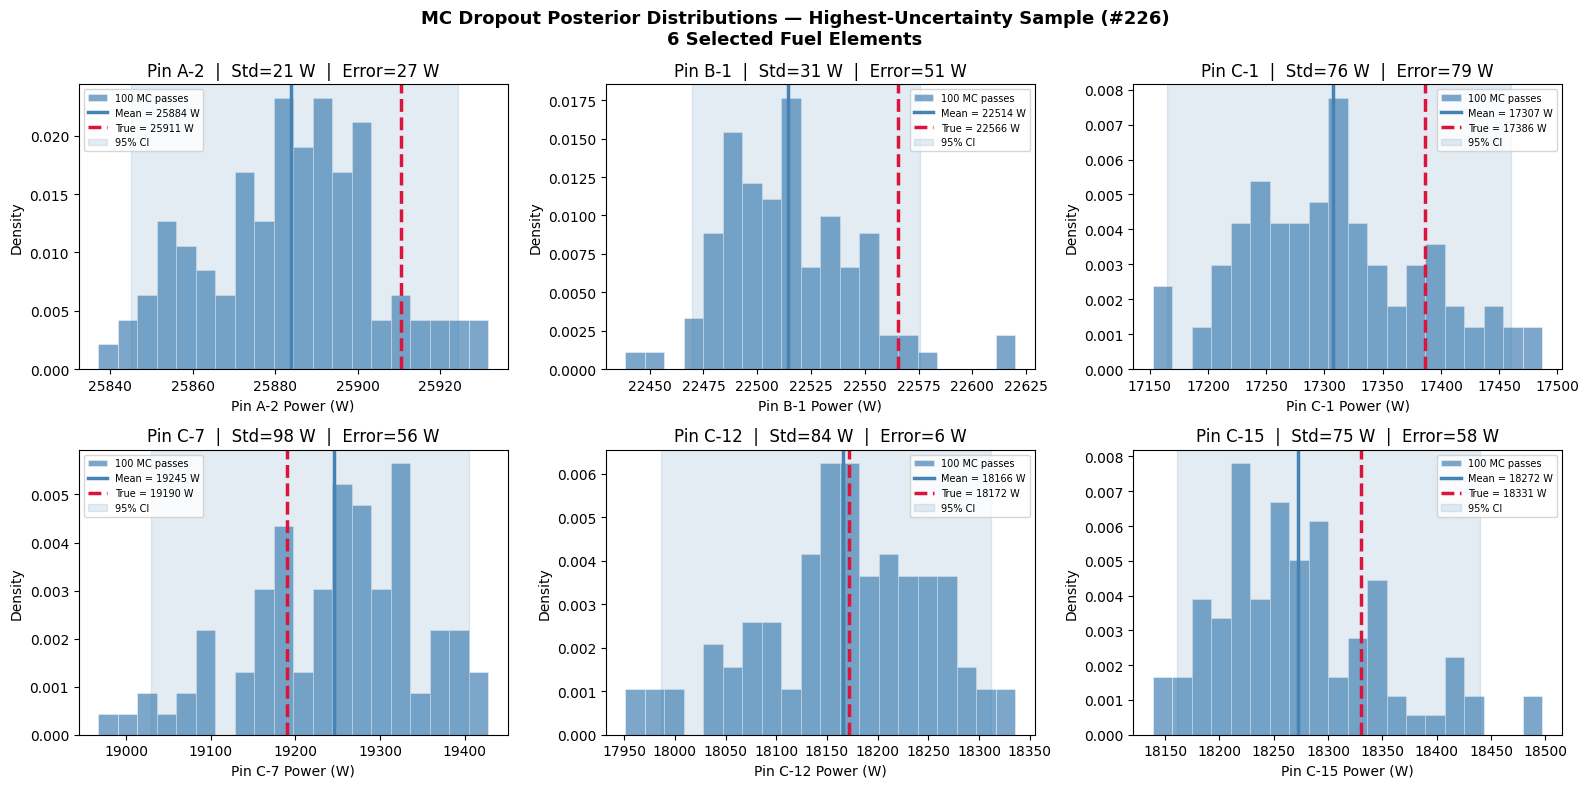

In [58]:
# Select the test sample with highest average std dev across all 22 outputs
avg_std_per_sample = std_pred.mean(axis=1)
sample_idx = np.argmax(avg_std_per_sample)

print(f'Highest-uncertainty test sample index : {sample_idx}')
print(f'Average predictive std dev            : {avg_std_per_sample[sample_idx]:.1f} ')

# Show the posterior distributions for 6 selected outputs for this sample
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax_i, (out_i, name) in enumerate(zip(selected_outputs, selected_names)):
    sample_preds = preds_W[:, sample_idx, out_i]   # 100 MC draws for this sample + output
    s_mean = sample_preds.mean()
    s_std  = sample_preds.std()
    s_lo   = np.percentile(sample_preds, 2.5)
    s_hi   = np.percentile(sample_preds, 97.5)
    s_true = y_test[sample_idx, out_i]

    ax = axes[ax_i]
    ax.hist(sample_preds, bins=20, color='steelblue', edgecolor='white',
            linewidth=0.4, density=True, alpha=0.7, label=f'{MC_SAMPLES} MC passes')
    ax.axvline(s_mean, color='steelblue', linewidth=2.5,
               label=f'Mean = {s_mean:.0f} W')
    ax.axvline(s_true, color='crimson', linewidth=2.5, linestyle='--',
               label=f'True = {s_true:.0f} W')
    ax.axvspan(s_lo, s_hi, alpha=0.15, color='steelblue', label='95% CI')
    ax.set_xlabel(f'Pin {name} Power (W)')
    ax.set_ylabel('Density')
    ax.set_title(f'Pin {name}  |  Std={s_std:.0f} W  |  Error={abs(s_mean-s_true):.0f} W')
    ax.legend(fontsize=7)

fig.suptitle(
    f'MC Dropout Posterior Distributions — Highest-Uncertainty Sample (#{sample_idx})\n'
    f'6 Selected Fuel Elements',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()